In [1]:
import os
import random
import math
import numpy as np
import pandas as pd
import time
import copy
import requests
import shutil
import cv2

from tqdm import tqdm
from glob import glob
from zipfile import ZipFile
from dataclasses import dataclass
from typing import List, Tuple, Union
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import (DataLoader, 
                              Dataset, 
                              random_split, 
                              WeightedRandomSampler)
from torch.optim import lr_scheduler

from torchvision.models import (resnet18, 
                                resnet50, 
                                ResNet50_Weights, 
                                efficientnet_v2_s, 
                                EfficientNet_V2_S_Weights)
from torchvision import datasets, transforms as T
from torchvision.transforms import functional

from torch.utils.tensorboard import SummaryWriter
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)
import seaborn as sns


2026-07-25 11:16:40.514678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784978200.693642      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784978200.746183      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784978201.205347      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784978201.205390      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784978201.205393      57 computation_placer.cc:177] computation placer alr

In [2]:
bold = f"\033[1m"
reset = f"\033[0m"

In [3]:
# TO check whether all the images contain jpg format

path_img = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images/*.*'
other_files = [i for i in glob(path_img) if not i.lower().endswith('.jpg')]
print(len(other_files))

0


In [4]:
# paths 
root_dir = '/kaggle/working/'
dataroot = os.path.join(root_dir, 'datasets')
train_data_path = os.path.join(root_dir, 'train.csv')
valid_data_path = os.path.join(root_dir, 'valid.csv')
test_data_path = os.path.join(root_dir, 'test.csv')
train_img_datasets = os.path.join(dataroot, 'train')
valid_img_datasets = os.path.join(dataroot, 'valid')
test_img_datasets = os.path.join(dataroot, 'test')
model_checkpoint = os.path.join(root_dir, 'model_checkpoint/ken_food_models')

In [5]:
# creating folders in the working directory
os.makedirs(train_img_datasets, exist_ok = True)
os.makedirs(valid_img_datasets, exist_ok = True)
os.makedirs(test_img_datasets, exist_ok = True)
os.makedirs(model_checkpoint, exist_ok = True)

In [6]:
# copying test.csv from input to working
shutil.copy2('/kaggle/input/open-cv-py-torch-project-2-classification-round-4/test.csv',
             test_data_path)

'/kaggle/working/test.csv'

In [7]:
# reading csv files of train.csv
df_train= pd.read_csv('/kaggle/input/open-cv-py-torch-project-2-classification-round-4/train.csv')

In [8]:
# splitting the data into train and valid
train_data,valid_data = train_test_split(df_train,
                                         test_size = 0.2,
                                         random_state  = 42)

In [9]:
# creating train and valid csv files
train_data.to_csv(train_data_path, index = False)
valid_data.to_csv(valid_data_path, index = False)

In [10]:
# function for Copying images from images folder to specified directory
def image_copy(name_path, src_path, dst_path):
    data = pd.read_csv(name_path)
    names = data.iloc[:,0].tolist()

    for i in names:
        name_jpg = str(i) + '.jpg'

        src_image = os.path.join(src_path, name_jpg)
        dst_image = os.path.join(dst_path, name_jpg)

        if os.path.exists(src_image):
            shutil.copy2(src_image, dst_image)
        else:
            print(f"Warning: {src_image} not found in {dst_image}")
            
            

In [11]:
# Copying images from images folder to specified train directory
image_copy(name_path = train_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = train_img_datasets)

In [12]:
# Copying images from images folder to specified test directory
image_copy(name_path = test_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = test_img_datasets)

In [13]:
# Copying images from images folder to specified test directory
image_copy(name_path = valid_data_path,
           src_path = '/kaggle/input/open-cv-py-torch-project-2-classification-round-4/images/images',
           dst_path = valid_img_datasets)

## <font style="color:green">1. Data Loader [10 Points]</font>

In this section, you have to write a class or methods, which will be used to get training and validation data loader.

You need to write a custom dataset class to load data.

**Note; There is   no separate validation data. , You will thus have to create your own validation set, by dividing the train data into train and validation data. Usually, we do 80:20 ratio for train and validation, respectively.**


For example:

```python
class KenyanFood13Dataset(Dataset):
    """
    
    """
    
    def __init__(self, *args):
    ....
    ...
    
    def __getitem__(self, idx):
    ...
    ...
    

```


```python
def get_data(args1, *args):
    ....
    ....
    return train_loader, test_loader
```

In [14]:
class Kenyanfood(Dataset):
    def __init__(self, csv_path, 
                 data_root, transform = None,
                 class_to_idx = None):
        """
        args:
        csv_path : path of csv files 'train.csv', 'valid.csv' and test.csv
        img_dir : path of images
        transform : preprocessing
        class_to_idx : text to number mapping
        
        """
        
        self.df = pd.read_csv(csv_path)
        self.data_root = data_root
        self.transform = transform

        # To check whether it is a test set
        self.is_test = 'class' not in self.df.columns
        
        # label encoding
        if not self.is_test:    
            if class_to_idx is None:
                unique_classes = sorted(self.df['class'].unique())
                self.class_to_idx = {class_name:idx for idx, class_name in enumerate(unique_classes)}
            else:
                self.class_to_idx = class_to_idx
        else:
            self.class_to_idx = None

    def __len__(self):
        """
            return length of the dataset
        """
        return len(self.df)

    def __getitem__(self, idx):
        # get the row of the data
        row = self.df.iloc[idx]
        
        # extract the image name
        img_name = str(row['id']) + '.jpg'
        img_path = os.path.join(self.data_root, img_name)

        # Read the image
        image = cv2.imread(img_path, 1)
        
        # Convert the image from bgr to rgb
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # converting to PIL image
        image = Image.fromarray(image)

        # apply transforms and return
        if self.transform:
            image = self.transform(image)

        # return only the image in case of test set
        if self.is_test:
            return image, str(row['id'])
        else:
            # convert the label into numeric
            label = row['class']
            numerical_label = self.class_to_idx[label]
            return image, torch.tensor(numerical_label)
        

In [15]:
# image preprocessing techniques applied to valid and test set
def image_preprocess_transforms(img_height, img_width, 
                                mean, std):
    preprocess = T.Compose([
        T.Resize((img_height, img_width), antialias = True),
        T.ToTensor(),
        T.Normalize(mean, std)
    ])

    return preprocess

In [16]:
def get_data(img_height, img_width, 
             batch_size, num_workers = 1):

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    #mean = [0.5768, 0.4622, 0.3460]
    #std = [0.2383, 0.2464, 0.2465]
    
    common_transforms = image_preprocess_transforms(img_height, img_width,
                                                    mean, std)

    # preprocessing applied to train images
    train_transforms = T.Compose([ 
        # Geometric & Scale Augmentations
        # Instead of a fixed Resize, this randomly crops a portion of the image 
        # and resizes it to 224x224. This makes the model invariant to zoom/scale.
        T.RandomResizedCrop((img_height, img_width), 
                            scale = (0.75, 1.0), 
                            ratio = (0.9, 1.1)),
        
        # Randomly flips the plate of food horizontally. 
        # A chapati or bowl of ugali is still the same food if flipped!
        T.RandomHorizontalFlip(p = 0.5),

        T.RandAugment(num_ops=2, magnitude=9),  # Auto-augmentation policy
    
        # Randomly rotates the image slightly (up to 15 degrees). 
        # Accounts for different camera angles when people take photos of food.
        T.RandomRotation(degrees = 15),
        
        # Photometric (Lighting) Augmentations
        # Subtly adjusts brightness, contrast, and saturation. 
        # Kept conservative (0.1) so it doesn't change a brown stew into a green one.
        T.ColorJitter(brightness = 0.2, 
                      contrast = 0.2, 
                      saturation = 0.2, 
                      hue = 0.05),

        T.RandomGrayscale(p=0.1),
 
        T.ToTensor(),
        
        T.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),

        T.Normalize(mean = mean, std = std),
    ])

    train_dataset  = Kenyanfood(
        csv_path = train_data_path, 
        data_root = train_img_datasets, 
        transform = train_transforms,
        class_to_idx = None
    )

    valid_dataset = Kenyanfood(
        csv_path = valid_data_path, 
        data_root = valid_img_datasets, 
        transform = common_transforms,
        class_to_idx = train_dataset.class_to_idx
    )

    test_dataset = Kenyanfood(
        csv_path = test_data_path, 
        data_root = test_img_datasets, 
        transform = common_transforms,
    )

    # Compute class weights for balanced sampling
    train_labels = train_dataset.df['class'].map(train_dataset.class_to_idx).values
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels]

    sampler = WeightedRandomSampler(
        weights = torch.DoubleTensor(sample_weights),
        num_samples = len(sample_weights),
        replacement = True
    )

    # train dataloader
    train_loader = DataLoader(train_dataset, batch_size = batch_size,
                              shuffle = sampler, num_workers = num_workers)

    # valid dataloader
    valid_loader = DataLoader(valid_dataset, batch_size = batch_size,
                              shuffle = False, num_workers = num_workers)

    # test dataloader
    test_loader = DataLoader(test_dataset, batch_size = batch_size,
                              shuffle = False, num_workers = num_workers)

    return (train_loader, 
            valid_loader, 
            test_loader, 
            train_dataset.class_to_idx)

## <font style="color:green">2. Configuration [5 Points]</font>

**Define your configuration here.**

For example:


```python
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 10 
    epochs_count: int = 50  
    init_learning_rate: float = 0.1  # initial learning rate for lr scheduler
    log_interval: int = 5  
    test_interval: int = 1  
    data_root: str = "/kaggle/input/opencv-pytorch-project-2-classification-round-3" 
    num_workers: int = 2  
    device: str = 'cuda'  
    
```

In [17]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 13
    IMG_WIDTH:   int = 224
    IMG_HEIGHT:  int = 224
    BATCH_SIZE:      int = 32
    NUM_WORKERS:     int = 4

@dataclass(frozen=True)
class TrainingConfig:  
    EPOCHS:          int = 200
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY:    float = 2e-2
    LABEL_SMOOTHING: float = 0.1
    DROPOUT: float = 0.5
    CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', 'kenya_food_models')
    LOG_DIR:        str   = "kenyan_food_res18"
    TEST_INTERVAL:  int   = 1
    MIXUP_ALPHA:     float = 0.5       # Mixup augmentation strength
    GRAD_CLIP:       float = 1.0
    EMA_DECAY:       float = 0.995    # Exponential Moving Average decay


@dataclass(frozen=True)
class InferenceConfig:
    BATCH_SIZE:  int = 32

In [18]:
def system_config(SEED_VALUE=42, package_list=None):
    """
    Configures the system environment for PyTorch-based operations.

    Args:
        SEED_VALUE (int): Seed value for random number generation. Default is 42.
        package_list (str): String containing a list of additional packages to install
        for Google Colab or Kaggle. Default is None.

    Returns:
        tuple: A tuple containing the device name as a string and a boolean indicating GPU availability.
    """

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

    def is_running_in_colab():
        return 'COLAB_GPU' in os.environ

    def is_running_in_kaggle():
        return 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

    #--------------------------------
    # Check for availability of GPUs.
    #--------------------------------
    if torch.cuda.is_available():
        print('Using CUDA GPU')

        # This section for installing packages required by Colab.
        if is_running_in_colab() or is_running_in_kaggle():
            print('Installing required packages...')
            !pip install {package_list}

        # Set the device to the first CUDA device.
        DEVICE = torch.device('cuda')
        print("Device: ", DEVICE)
        GPU_AVAILABLE = True

        torch.cuda.manual_seed(SEED_VALUE)
        torch.cuda.manual_seed_all(SEED_VALUE)

        # Performance and deterministic behavior.
        torch.backends.cudnn.enabled = True       # Provides highly optimized primitives for DL operations.
        torch.backends.cudnn.deterministic = True # Insures deterministic even when above cudnn is enabled.
        torch.backends.cudnn.benchmark = False    # Setting to True can cause non-deterministic behavior.

    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print('Using Apple Silicon GPU')

        # Set the device to the Apple Silicon GPU Metal Performance Shader (MPS).
        DEVICE = torch.device("mps")
        print("Device: ", DEVICE)
        # Environment variable that allows PyTorch to fall back to CPU execution
        # when encountering operations that are not currently supported by MPS.
        os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
        GPU_AVAILABLE = True

        torch.mps.manual_seed(SEED_VALUE)
        torch.use_deterministic_algorithms(True)

    else:
        print('Using CPU')
        DEVICE = torch.device('cpu')
        print("Device: ", DEVICE)
        GPU_AVAILABLE = False

        if is_running_in_colab() or is_running_in_kaggle():
            print('Installing required packages...')
            !pip install {package_list}
            print('Note: Change runtime type to GPU for better performance.')

        torch.use_deterministic_algorithms(True)

    return str(DEVICE), GPU_AVAILABLE

In [19]:
DEVICE, GPU_AVAILABLE = system_config()

Using CUDA GPU
Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 28.6 MB/s eta 0:00:00
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
  Attempting uninstall: alabaster
    Found existing installation: alabaster 1.0.0
    Uninstalling alabaster-1.0.0:
      Successfully uninstalled alabaster-1.0.0
  Attempting uninstall: sphinx
    Found existing installation: Sphinx 8.2.3
    Uninstalling Sphinx-8.2.3:
      Successfully uninstalled Sphinx-8.2.3
Device:  cuda


In [20]:
train_loader, valid_loader, test_loader, class_to_idx = get_data(DatasetConfig.IMG_WIDTH, 
                                                                 DatasetConfig.IMG_HEIGHT,
                                                                 DatasetConfig.BATCH_SIZE, 
                                                                 DatasetConfig.NUM_WORKERS)

## <font style="color:green">3. Evaluation Metric [10 Points]</font>

**Define methods or classes that will be used in model evaluation. For example, accuracy, f1-score etc.**

In [21]:
# ==================== CONFUSION MATRIX PLOT ====================

def plot_confusion_matrix(conf_matrix, class_names, 
                          epoch, save_dir='confusion_matrices'):
    os.makedirs(save_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix - Epoch {epoch}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    save_path = os.path.join(save_dir, f'conf_matrix_epoch_{epoch}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to: {save_path}")

## <font style="color:green">4. Train and Validation [5 Points]</font>


**Write the methods or classes to be used for training and validation.**

In [22]:
def train(
    DEVICE, 
    train_config: TrainingConfig,
    dataset_config: DatasetConfig, 
    model: nn.Module,
    optimizer: torch.optim.Optimizer, 
    train_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int,
    ema_model
) -> Tuple[float, float]:

    # change model in training mode
    model.train()

    acc_metric = MulticlassAccuracy(num_classes = dataset_config.NUM_CLASSES, 
                                    average = 'micro')
    mean_metric = MeanMetric()

    status = f"Train:\t {bold}Epoch: {epoch_idx}/{total_epochs}{reset}"

    prog_bar = tqdm(train_loader, bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}')

    prog_bar.set_description(status)

    for data, target in prog_bar:

        # send data and target to appropriate device
        data, target = data.to(DEVICE), target.to(DEVICE)

        # MIXUP: 80% chance per batch
        use_mixup = np.random.rand() < 0.5 and epoch_idx < total_epochs * 0.75  # turn off mixup late in training
        if use_mixup:
            data, target_a, target_b, lam = mixup_data(data, target, train_config.MIXUP_ALPHA, DEVICE)

        optimizer.zero_grad()
        output = model(data)

        if use_mixup:
            loss = mixup_criterion(
                lambda pred, tgt: F.cross_entropy(pred, tgt, label_smoothing=train_config.LABEL_SMOOTHING),
                output, target_a, target_b, lam
            )
        else:
            loss = F.cross_entropy(output, 
                                   target, 
                                   label_smoothing=train_config.LABEL_SMOOTHING)

        # Find gradients w.r.t training parameters
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(),
                                       max_norm = train_config.GRAD_CLIP)
        
        # update the parameters using gradients
        optimizer.step()

        # Update EMA after optimizer step
        ema_model.update(model)
        
        # Batch loss
        batch_loss = mean_metric(loss.item(), weight = data.shape[0])

        # Accuracy on non-mixup batches only (mixup has two labels)
        if not use_mixup:
            prob = F.softmax(output, dim=1)
            pred_idx = prob.detach().argmax(dim=1)
            batch_acc = acc_metric(pred_idx.cpu(), target.cpu())
            step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        else:
            step_status = status + f"\tLoss:{mean_metric.compute():.4f}, Acc: -- (mixup)"

        prog_bar.set_description(step_status)

    epoch_loss = mean_metric.compute()
    epoch_acc = acc_metric.compute() if acc_metric.update_called else torch.tensor(0.0)

    prog_bar.close()

    return epoch_loss, epoch_acc
        

In [23]:
def validate(
    DEVICE,
    train_config: TrainingConfig,
    dataset_config: DatasetConfig,
    model: nn.Module,
    valid_loader: torch.utils.data.DataLoader,
    epoch_idx: int,
    total_epochs: int
) -> Tuple[float, float]:
    #
    model.eval()

    acc_metric = MulticlassAccuracy(num_classes=dataset_config.NUM_CLASSES, average="micro")
    mean_metric = MeanMetric()

    # Confusion matrix
    conf_matrix_metric = MulticlassConfusionMatrix(num_classes=dataset_config.NUM_CLASSES).to(DEVICE)

    status = f"Valid:\t{bold}Epoch: {epoch_idx}/{total_epochs}{reset}"

    prog_bar = tqdm(valid_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}')

    prog_bar.set_description(status)

    all_preds = []
    all_targets = []
    
    for data, target in prog_bar:

        # Send data and target to appropriate device.
        data, target = data.to(DEVICE), target.to(DEVICE)

        # Get the model's predicted logits.
        with torch.no_grad():
            output = model(data)

        # Compute the CE-Loss.
        valid_loss = F.cross_entropy(output, 
                                     target, 
                                     label_smoothing = TrainingConfig.LABEL_SMOOTHING).item()

        # Convert model's logits to probability scores.
        prob = F.softmax(output, dim=1)

        # Get the class id for the maximum score.
        pred_idx = prob.detach().argmax(dim=1)

        # Batch validation loss.
        batch_loss = mean_metric(valid_loss, weight=data.shape[0])

        # Batch validation accuracy.
        batch_acc = acc_metric(pred_idx.cpu(), target.cpu())

        # Update confusion matrix
        conf_matrix_metric.update(pred_idx, target)

        all_preds.extend(pred_idx.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

        # Update progress bar description.
        step_status = status + f"\tLoss: {mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        prog_bar.set_description(step_status)


    valid_loss = mean_metric.compute()
    valid_acc = acc_metric.compute()
    conf_matrix = conf_matrix_metric.compute().cpu().numpy()
    prog_bar.close()

    return valid_loss, valid_acc, conf_matrix, all_preds, all_targets

## <font style="color:green">5. Model [5 Points]</font>

**Define your model in this section.**

**You are allowed to use any pre-trained model.**

# function defining the model parameters we will only unfreeze the layer 4 parameters
def get_resnet_50(num_classes):

    model_res_50 = resnet50(weights = "DEFAULT")

    # Freeze all parameters across the network
    for params in model_res_50.parameters():
        params.requires_grad = False

    for params in model_res_50.layer3.parameters():
        params.requires_grad = True

    # Unfreeze layer 4 parameters specifically
    for params in model_res_50.layer4.parameters():
        params.requires_grad = True

    #for params in model_res_50.layer4[-2].parameters():
    #    params.requires_grad = True

    # Replace the final fully connected layer
    model_fc_in_features = model_res_50.fc.in_features
    model_res_50.fc = nn.Sequential(
        nn.Dropout(p=0.4), # 40% of the connections are randomly cut during training
        nn.Linear(in_features = model_fc_in_features, out_features = num_classes)
    )

    return model_res_50

model_50 = get_resnet_50(num_classes = DatasetConfig.NUM_CLASSES)

print(summary(
    model_50,
))

model_50 = model_50.float().to(DEVICE)

optimizer_50 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_50.parameters()),
    lr = TrainingConfig.LEARNING_RATE,
    weight_decay=1e-2
)

optimizer_50 = optim.Adam([
    {'params': model_50.layer3.parameters(), 'lr': 1e-4},
    {'params': model_50.layer4.parameters(), 'lr': 3e-4},
    {'params': model_50.fc.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

# convnext_tiny model

In [24]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

def get_convnext(num_classes):
    # Load state-of-the-art ConvNeXt Tiny
    weights = ConvNeXt_Tiny_Weights.DEFAULT
    model = convnext_tiny(weights=weights)
    
    # Replace the classification head
    # ConvNeXt uses a classifier block, the linear layer is at index 2
    model_fc_in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p = TrainingConfig.DROPOUT), 
        nn.Linear(model_fc_in_features, 512),
        nn.ReLU(inplace = True),
        nn.Dropout(p = 0.3),
        nn.Linear(512, num_classes)
    )
    
    return model

In [25]:
model_net = get_convnext(num_classes=DatasetConfig.NUM_CLASSES)
print(summary(
    model_net,
))

model_net = model_net.float().to(DEVICE)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 179MB/s]  


Layer (type:depth-idx)                        Param #
ConvNeXt                                      --
├─Sequential: 1-1                             --
│    └─Conv2dNormActivation: 2-1              --
│    │    └─Conv2d: 3-1                       4,704
│    │    └─LayerNorm2d: 3-2                  192
│    └─Sequential: 2-2                        --
│    │    └─CNBlock: 3-3                      79,296
│    │    └─CNBlock: 3-4                      79,296
│    │    └─CNBlock: 3-5                      79,296
│    └─Sequential: 2-3                        --
│    │    └─LayerNorm2d: 3-6                  192
│    │    └─Conv2d: 3-7                       73,920
│    └─Sequential: 2-4                        --
│    │    └─CNBlock: 3-8                      306,048
│    │    └─CNBlock: 3-9                      306,048
│    │    └─CNBlock: 3-10                     306,048
│    └─Sequential: 2-5                        --
│    │    └─LayerNorm2d: 3-11                 384
│    │    └─Conv2d: 3-12   

In [26]:
# FREEZE everything except classifier + last stage initially
for p in model_net.features[0].parameters():  # stem
    p.requires_grad = False
for p in model_net.features[1].parameters():  # stage 1
    p.requires_grad = False
for p in model_net.features[2].parameters():  # stage 2
    p.requires_grad = False
for p in model_net.features[3].parameters():  # stage 3
    p.requires_grad = False
# features[4] (stage 4) + classifier stay trainable

In [27]:
# Create optimizer with ALL param groups upfront
# Frozen params are included but ignored (requires_grad=False)
# When we unfreeze later, optimizer automatically picks them up
optimizer_net = optim.AdamW([
    {'params': model_net.classifier[2].parameters(), 'lr': 1e-3},   # head
    {'params': model_net.features[4].parameters(), 'lr': 5e-4},   # stage 4 (last)
    {'params': model_net.features[3].parameters(), 'lr': 1e-4},   # stage 3
    {'params': model_net.features[2].parameters(), 'lr': 5e-5},   # stage 2
    {'params': model_net.features[1].parameters(), 'lr': 1e-5},   # stage 1
    {'params': model_net.features[0].parameters(), 'lr': 1e-5},   # stem
],
    
     weight_decay = TrainingConfig.WEIGHT_DECAY       # Adds L2 regularization to prevent overfitting
)

In [28]:
# ==================== EMA (EXPONENTIAL MOVING AVERAGE) ====================
# This is HUGE for validation accuracy. It smooths out weight updates.

class ModelEMA:
    def __init__(self, model, decay=0.9999):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    def update(self, model):
        with torch.no_grad():
            for ema_p, p in zip(self.ema.parameters(), model.parameters()):
                ema_p.data.mul_(self.decay).add_(p.data, alpha=1 - self.decay)

ema = ModelEMA(model_net, decay=TrainingConfig.EMA_DECAY)

In [29]:
# ==================== MIXUP ====================

def mixup_data(x, y, alpha = 0.4, device='cuda'):
    """Mixup augmentation: creates synthetic training examples"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

## Efficient Net model

In [30]:
def get_efficientnet_v2(num_classes, pretrained=True):
    weights = EfficientNet_V2_S_Weights.DEFAULT if pretrained else None
    model = efficientnet_v2_s(weights=weights)

    # Freeze all parameters initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 blocks (features[6], features[7], features[8])
    for param in model.features[6:].parameters():
        param.requires_grad = True

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model

In [31]:
model_efficient = get_efficientnet_v2(num_classes=DatasetConfig.NUM_CLASSES)
print(summary(model_efficient))
model_efficient = model_efficient.float().to(DEVICE)

# ==================== OPTIMIZER ====================

optimizer_efficient = optim.AdamW(
    model_efficient.parameters(),
    lr=TrainingConfig.LEARNING_RATE,
    weight_decay=TrainingConfig.WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 150MB/s] 


Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 (648)
│    │    └─BatchNorm2d: 3-2                            (48)
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─FusedMBConv: 3-4                            (5,232)
│    │    └─FusedMBConv: 3-5                            (5,232)
│    └─Sequential: 2-3                                  --
│    │    └─FusedMBConv: 3-6                            (25,632)
│    │    └─FusedMBConv: 3-7                            (92,640)
│    │    └─FusedMBConv: 3-8                            (92,640)
│    │    └─FusedMBConv: 3-9                            (92,640)
│    └─Sequential: 2-4                                  --
│    │    └─

## <font style="color:green">6. Utils [5 Points]</font>

**Define those methods or classes, which have  not been covered in the above sections.**

In [32]:
def main(
    DEVICE: torch.device,
    model: nn.Module,
    optimizer: optim.Adam,
    ema_model,
    ckpt_dir: str,
    summary_writer: torch.utils.tensorboard.writer.SummaryWriter,
    data_config: DatasetConfig,
    train_config: TrainingConfig,
    class_to_idx
  ) -> dict:


    # data loader
    train_loader, valid_loader, _, _ = get_data(data_config.IMG_WIDTH, 
                                                data_config.IMG_HEIGHT,
                                                data_config.BATCH_SIZE, 
                                                data_config.NUM_WORKERS)
    # Schedulers
    warmup_epochs = 5
    cosine_scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, 
        T_mult=2, eta_min=1e-7
    )
    """plateau_scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', 
        factor=0.5, patience=5, 
        threshold=0.01,
    )"""


    # INITIALIZE EARLY STOPPING TRACKERS
    best_loss = torch.tensor(np.inf)
    early_stopping_patience = 12
    early_stopping_counter = 0
    best_weights = copy.deepcopy(model.state_dict())
    best_ema_weights = copy.deepcopy(ema_model.ema.state_dict())

    # epoch train/valid loss
    epoch_train_loss = []
    epoch_valid_loss = []

    # epoch train/valid accuracy
    epoch_train_acc = []
    epoch_valid_acc = []

    # Get class names for confusion matrix
    idx_to_class = {idx: name for name, idx in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    # trainig time measurement
    t_begin = time.time()

    for epoch in range(train_config.EPOCHS):
        
        # ========== SAFE PROGRESSIVE UNFREEZING (no add_param_group!) ==========
        # Just toggle requires_grad. Optimizer already knows these params.

        if epoch == 5:
            print(f"\n{'='*60}")
            print("UNFREEZING: Stage 3 (features[3]) | LR: 1e-4")
            print(f"{'='*60}\n")
            for p in model.features[3].parameters():
                p.requires_grad = True

        if epoch == 12:
            print(f"\n{'='*60}")
            print("UNFREEZING: Stage 2 (features[2]) | LR: 5e-5")
            print(f"{'='*60}\n")
            for p in model.features[2].parameters():
                p.requires_grad = True

        if epoch == 20:
            print(f"\n{'='*60}")
            print("UNFREEZING: Stage 1 + Stem | LR: 1e-5")
            print(f"{'='*60}\n")
            for p in model.features[1].parameters():
                p.requires_grad = True
            for p in model.features[0].parameters():
                p.requires_grad = True

        train_loss, train_acc = train(DEVICE, train_config, 
                                      data_config, model,
                                      optimizer, train_loader, 
                                      epoch+1, train_config.EPOCHS, 
                                      ema_model)
        
        val_loss, val_accuracy, conf_matrix, all_preds, all_targets = validate(DEVICE, train_config, 
                                                                               data_config, ema_model.ema,
                                                                               valid_loader, epoch+1, 
                                                                               train_config.EPOCHS)

         # Step scheduler (skip warmup)
        if epoch >= warmup_epochs:
            cosine_scheduler.step()
        else:
            # Warmup: linearly scale all LRs
            lr_scale = (epoch + 1) / warmup_epochs
            for pg in optimizer.param_groups:
                pg['lr'] = pg.get('initial_lr', pg['lr']) * lr_scale

        current_lr = optimizer.param_groups[0]['lr']
        
        summary_writer.add_scalar('Learning_Rate', current_lr, epoch)

        train_loss_stat = f"{bold}Train Loss: {train_loss:.4f}{reset}"
        train_acc_stat = f"{bold}Train Acc: {train_acc:.4f}{reset}"

        val_loss_stat = f"{bold}Val Loss: {val_loss:.4f}{reset}"
        val_acc_stat = f"{bold}Val Acc: {val_accuracy:.4f}{reset}"

        print(f"\n{train_loss_stat:<30}{train_acc_stat}")
        print(f"{val_loss_stat:<30}{val_acc_stat}")
        print(f"Current Learning Rate: {current_lr}\n")


        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)

        epoch_valid_loss.append(val_loss)
        epoch_valid_acc.append(val_accuracy)

        summary_writer.add_scalar('Loss/Train',train_loss, epoch)
        summary_writer.add_scalar('Accuracy/Train', train_acc, epoch)

        summary_writer.add_scalar('Loss/Validation', val_loss, epoch)
        summary_writer.add_scalar('Accuracy/Validation', val_accuracy, epoch)

        # add scalars (loss/accuracy) to tensorboard
        summary_writer.add_scalars('Loss/train-val', {'train': train_loss,
                                       'validation': val_loss}, epoch)
        summary_writer.add_scalars('Accuracy/train-val', {'train': train_acc,
                                           'validation': val_accuracy}, epoch)

        # Plot confusion matrix every 5 epochs and at the end
        if (epoch + 1) % 5 == 0 or epoch == 0:
            plot_confusion_matrix(conf_matrix, class_names, epoch + 1)

        # CONDITIONAL UPDATES & EARLY STOPPING CHECK
        if val_loss < best_loss:
            best_loss = val_loss
            print(f"\nEMA Model Improved... Saving... ", end="")
            best_ema_weights = copy.deepcopy(ema_model.ema.state_dict())
            torch.save(ema_model.ema.state_dict(), os.path.join(ckpt_dir, "best_ema_model.pth"))
            torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_model.pth"))
            print("Done.\n")
            
            # Reset the early stopping counter since we hit a new milestone
            early_stopping_counter = 0
            
        else:
            # Model stagnated or overfit; increment the penalty counter
            early_stopping_counter += 1
            print(f"Validation loss did not improve. Early Stopping: {early_stopping_counter}/{early_stopping_patience}\n")

        # Kill the loop if early stopping criterion is hit
        if early_stopping_counter >= early_stopping_patience:
            print(f"{'='*72}")
            print(f"Early Stopping Triggered! Training stopped at epoch {epoch+1} to avoid overfitting.")
            print(f"{'='*72}\n")
            break

        print(f"{'='*72}\n")

    print(f"Total time: {(time.time() - t_begin):.2f}s, Best Loss: {best_loss:.3f}")

    # Load best EMA weights for final evaluation
    ema_model.ema.load_state_dict(best_ema_weights)
    model.load_state_dict(best_ema_weights)  # Also load into main model for inference

    # Plot final confusion matrix on best model
    print("\nGenerating final confusion matrix on best model...")
    _, _, final_conf_matrix, _, _ = validate(
        DEVICE, train_config, data_config, model,
        valid_loader, train_config.EPOCHS, train_config.EPOCHS
    )
    plot_confusion_matrix(final_conf_matrix, class_names, 
                          "FINAL_BEST", save_dir='confusion_matrices')


    history = dict(model = model,
                   ema_model=ema_model.ema,
                   train_loss = epoch_train_loss,
                   train_acc = epoch_train_acc,
                   valid_loss = epoch_valid_loss,
                   valid_acc = epoch_valid_acc,
                   train_config = train_config,
                   data_config = data_config,
                   class_to_idx=class_to_idx)

    
    return history

In [33]:
def plot_results(
    metrics,
    title=None,
    ylabel=None,
    ylim=None,
    metric_name=None,
    color=None,
    training_config=TrainingConfig()):

    fig, ax = plt.subplots(figsize=(15, 4))

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, len(metrics[0]) - 1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

In [34]:
def create_checkpoint_dir(checkpoint_dir):

    # Create a new checkpoint directory every time.
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    print(f"Checkpoint directory: {checkpoint_dir}")
    return checkpoint_dir

In [35]:
CKPT_DIR = create_checkpoint_dir(TrainingConfig.CHECKPOINT_DIR)

%load_ext tensorboard
%tensorboard --logdir {TrainingConfig.LOG_DIR}

Checkpoint directory: model_checkpoint/kenya_food_models


<IPython.core.display.Javascript object>

## <font style="color:green">7. Experiment [5 Points]</font>

**Choose your optimizer and LR-scheduler and use the above methods and classes to train your model.**

Valid:	Epoch: 1/200	Loss: 1.7947, Acc: 0.6445: 100%|██████████| 41/41 [00:13<00:00,  2.98it/s]



Train Loss: 1.8687    Train Acc: 0.5327
Val Loss: 1.7947      Val Acc: 0.6445
Current Learning Rate: 0.0002



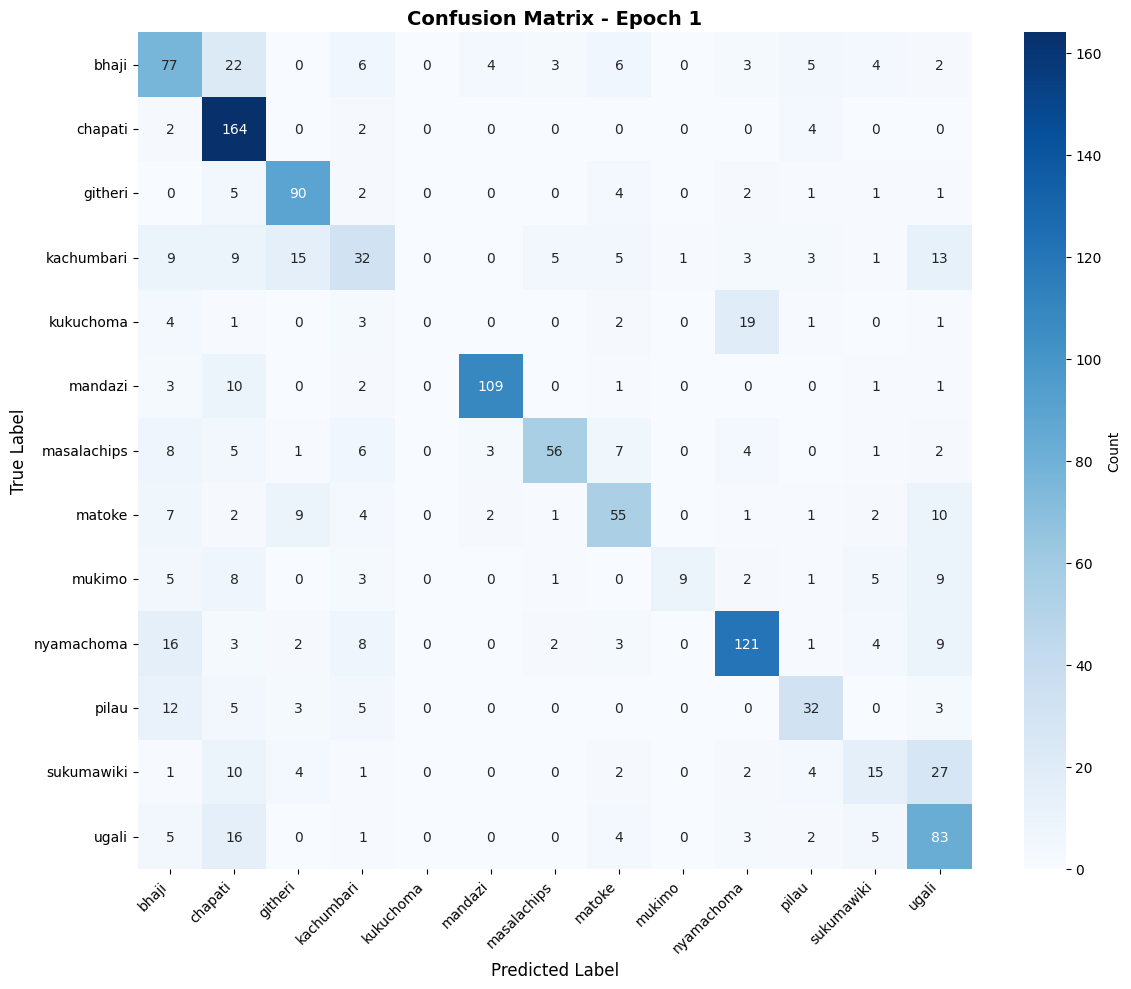

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_1.png

EMA Model Improved... Saving... Done.




Train:	 Epoch: 2/200	Loss:1.5933, Acc: -- (mixup): 100%|██████████| 164/164 [01:10<00:00,  2.34it/s]
Valid:	Epoch: 2/200	Loss: 1.3797, Acc: 0.7003: 100%|██████████| 41/41 [00:11<00:00,  3.51it/s]



Train Loss: 1.5933    Train Acc: 0.6350
Val Loss: 1.3797      Val Acc: 0.7003
Current Learning Rate: 0.0004


EMA Model Improved... Saving... Done.




Train:	 Epoch: 3/200	Loss:1.5426, Acc: -- (mixup): 100%|██████████| 164/164 [01:10<00:00,  2.33it/s]
Valid:	Epoch: 3/200	Loss: 1.2547, Acc: 0.7240: 100%|██████████| 41/41 [00:11<00:00,  3.48it/s]



Train Loss: 1.5426    Train Acc: 0.6566
Val Loss: 1.2547      Val Acc: 0.7240
Current Learning Rate: 0.0006


EMA Model Improved... Saving... Done.




Train:	 Epoch: 4/200	Loss:1.5443, Acc: -- (mixup): 100%|██████████| 164/164 [01:08<00:00,  2.38it/s]
Valid:	Epoch: 4/200	Loss: 1.1991, Acc: 0.7332: 100%|██████████| 41/41 [00:11<00:00,  3.44it/s]



Train Loss: 1.5443    Train Acc: 0.6767
Val Loss: 1.1991      Val Acc: 0.7332
Current Learning Rate: 0.0008


EMA Model Improved... Saving... Done.




Valid:	Epoch: 5/200	Loss: 1.1635, Acc: 0.7370: 100%|██████████| 41/41 [00:11<00:00,  3.53it/s]



Train Loss: 1.4987    Train Acc: 0.6874
Val Loss: 1.1635      Val Acc: 0.7370
Current Learning Rate: 0.001



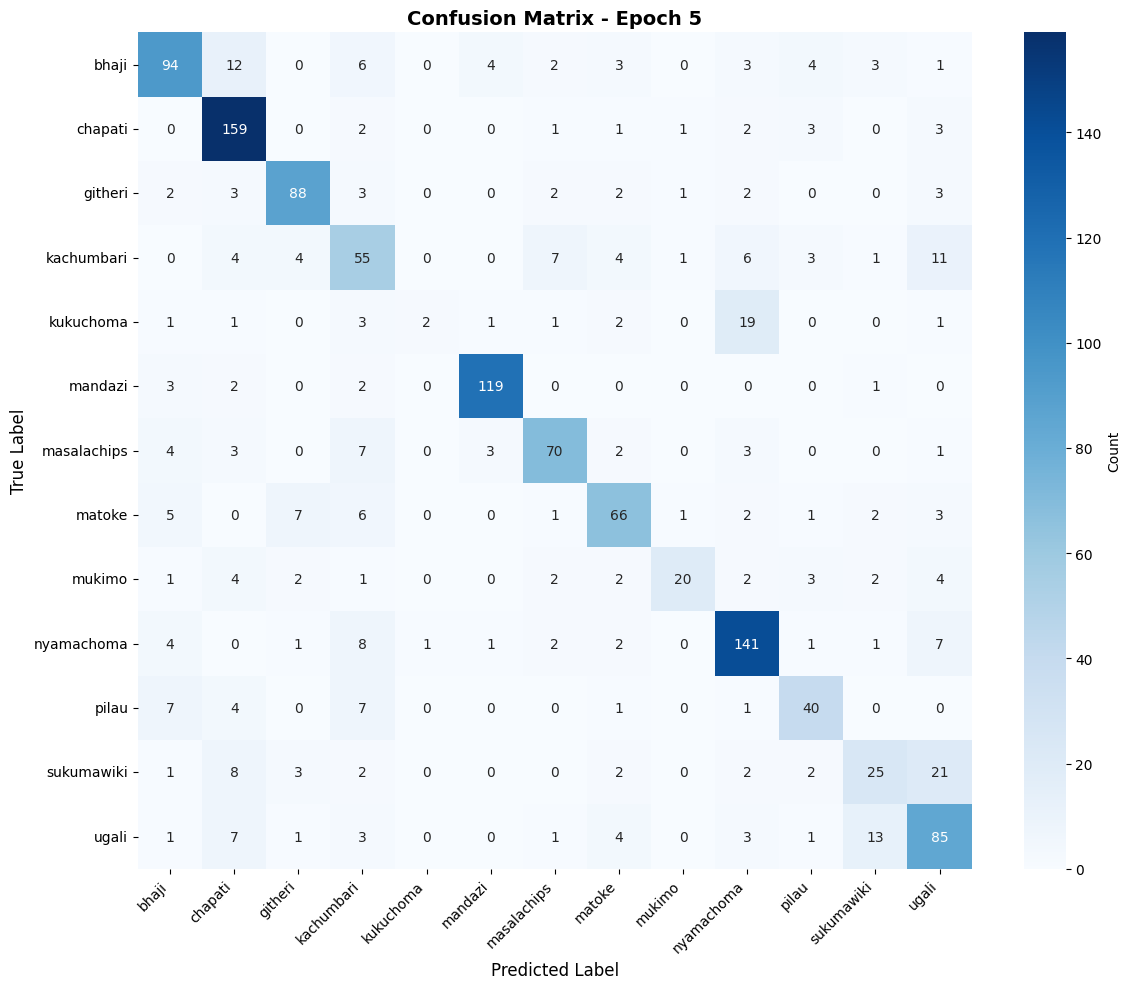

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_5.png

EMA Model Improved... Saving... Done.



UNFREEZING: Stage 3 (features[3]) | LR: 1e-4



Train:	 Epoch: 6/200	Loss:1.5024, Acc: -- (mixup): 100%|██████████| 164/164 [01:17<00:00,  2.11it/s]
Valid:	Epoch: 6/200	Loss: 1.1385, Acc: 0.7523: 100%|██████████| 41/41 [00:11<00:00,  3.47it/s]



Train Loss: 1.5024    Train Acc: 0.6963
Val Loss: 1.1385      Val Acc: 0.7523
Current Learning Rate: 0.000975530705321762


EMA Model Improved... Saving... Done.




Valid:	Epoch: 7/200	Loss: 1.1241, Acc: 0.7531: 100%|██████████| 41/41 [00:11<00:00,  3.53it/s]



Train Loss: 1.4483    Train Acc: 0.7124
Val Loss: 1.1241      Val Acc: 0.7531
Current Learning Rate: 0.0009045180463377549


EMA Model Improved... Saving... Done.




...


Train Loss: 1.4764    Train Acc: 0.7213
Val Loss: 1.1090      Val Acc: 0.7653
Current Learning Rate: 0.0007939132368836219


EMA Model Improved... Saving... Done.




Train:	 Epoch: 9/200	Loss:1.4220, Acc: -- (mixup): 100%|██████████| 164/164 [01:16<00:00,  2.16it/s]
Valid:	Epoch: 9/200	Loss: 1.0984, Acc: 0.7615: 100%|██████████| 41/41 [00:11<00:00,  3.51it/s]



Train Loss: 1.4220    Train Acc: 0.7373
Val Loss: 1.0984      Val Acc: 0.7615
Current Learning Rate: 0.0006545430463377549


EMA Model Improved... Saving... Done.




Train:	 Epoch: 10/200	Loss:1.4130, Acc: -- (mixup): 100%|██████████| 164/164 [01:16<00:00,  2.15it/s]
Valid:	Epoch: 10/200	Loss: 1.0914, Acc: 0.7737: 100%|██████████| 41/41 [00:11<00:00,  3.44it/s]



Train Loss: 1.4130    Train Acc: 0.7373
Val Loss: 1.0914      Val Acc: 0.7737
Current Learning Rate: 0.0005000499999999999



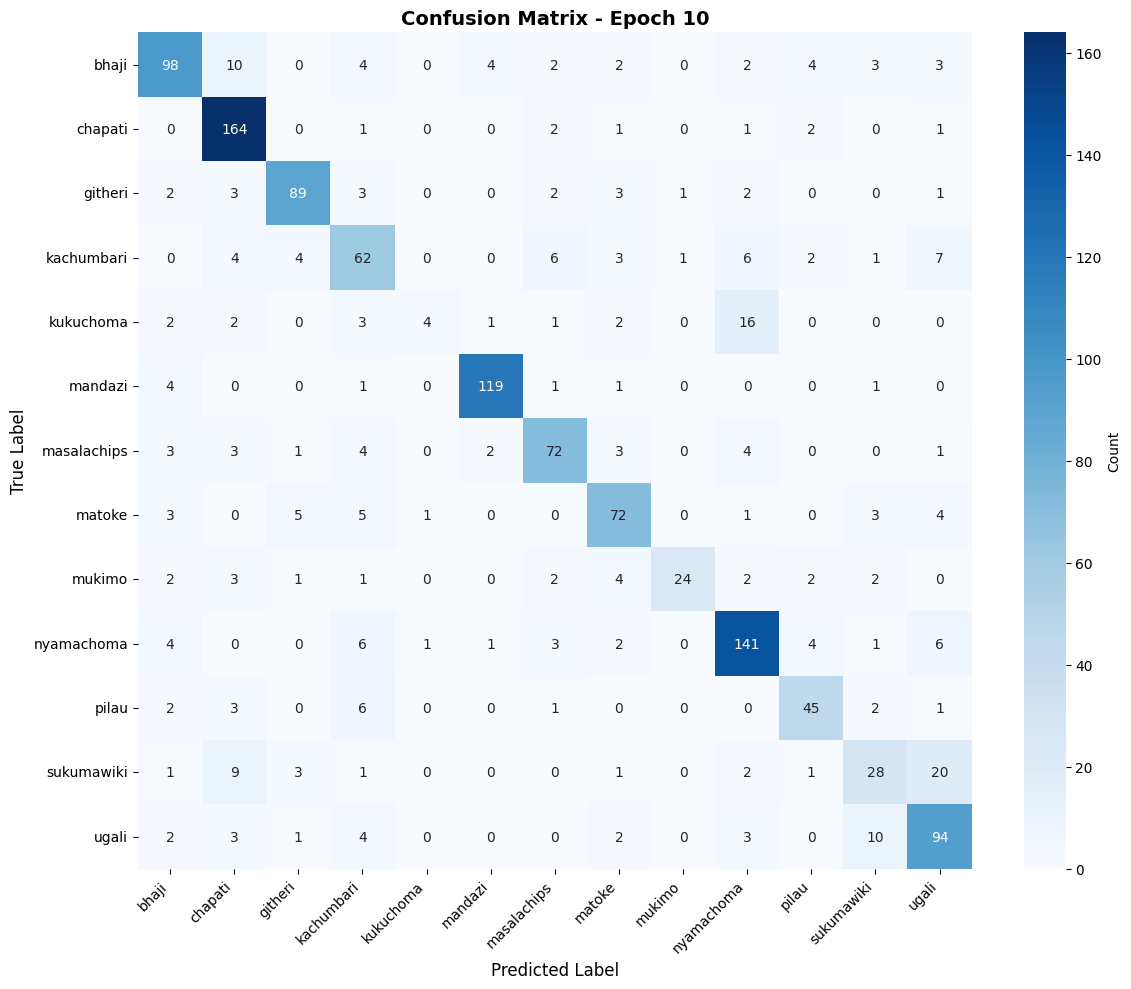

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_10.png

EMA Model Improved... Saving... Done.




Valid:	Epoch: 11/200	Loss: 1.0861, Acc: 0.7745: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.3872    Train Acc: 0.7684
Val Loss: 1.0861      Val Acc: 0.7745
Current Learning Rate: 0.00034555695366224505


EMA Model Improved... Saving... Done.




Valid:	Epoch: 12/200	Loss: 1.0801, Acc: 0.7752: 100%|██████████| 41/41 [00:11<00:00,  3.50it/s]



Train Loss: 1.3415    Train Acc: 0.7679
Val Loss: 1.0801      Val Acc: 0.7752
Current Learning Rate: 0.0002061867631163781


EMA Model Improved... Saving... Done.



UNFREEZING: Stage 2 (features[2]) | LR: 5e-5



...


Train Loss: 1.3349    Train Acc: 0.7791
Val Loss: 1.0757      Val Acc: 0.7806
Current Learning Rate: 9.558195366224507e-05


EMA Model Improved... Saving... Done.




Train:	 Epoch: 14/200	Loss:1.3474, Acc: -- (mixup): 100%|██████████| 164/164 [01:17<00:00,  2.11it/s]
Valid:	Epoch: 14/200	Loss: 1.0732, Acc: 0.7836: 100%|██████████| 41/41 [00:12<00:00,  3.33it/s]



Train Loss: 1.3474    Train Acc: 0.7825
Val Loss: 1.0732      Val Acc: 0.7836
Current Learning Rate: 2.456929467823799e-05


EMA Model Improved... Saving... Done.




Train:	 Epoch: 15/200	Loss:1.3521, Acc: -- (mixup): 100%|██████████| 164/164 [01:17<00:00,  2.12it/s]
Valid:	Epoch: 15/200	Loss: 1.0708, Acc: 0.7867: 100%|██████████| 41/41 [00:11<00:00,  3.60it/s]



Train Loss: 1.3521    Train Acc: 0.7825
Val Loss: 1.0708      Val Acc: 0.7867
Current Learning Rate: 0.001



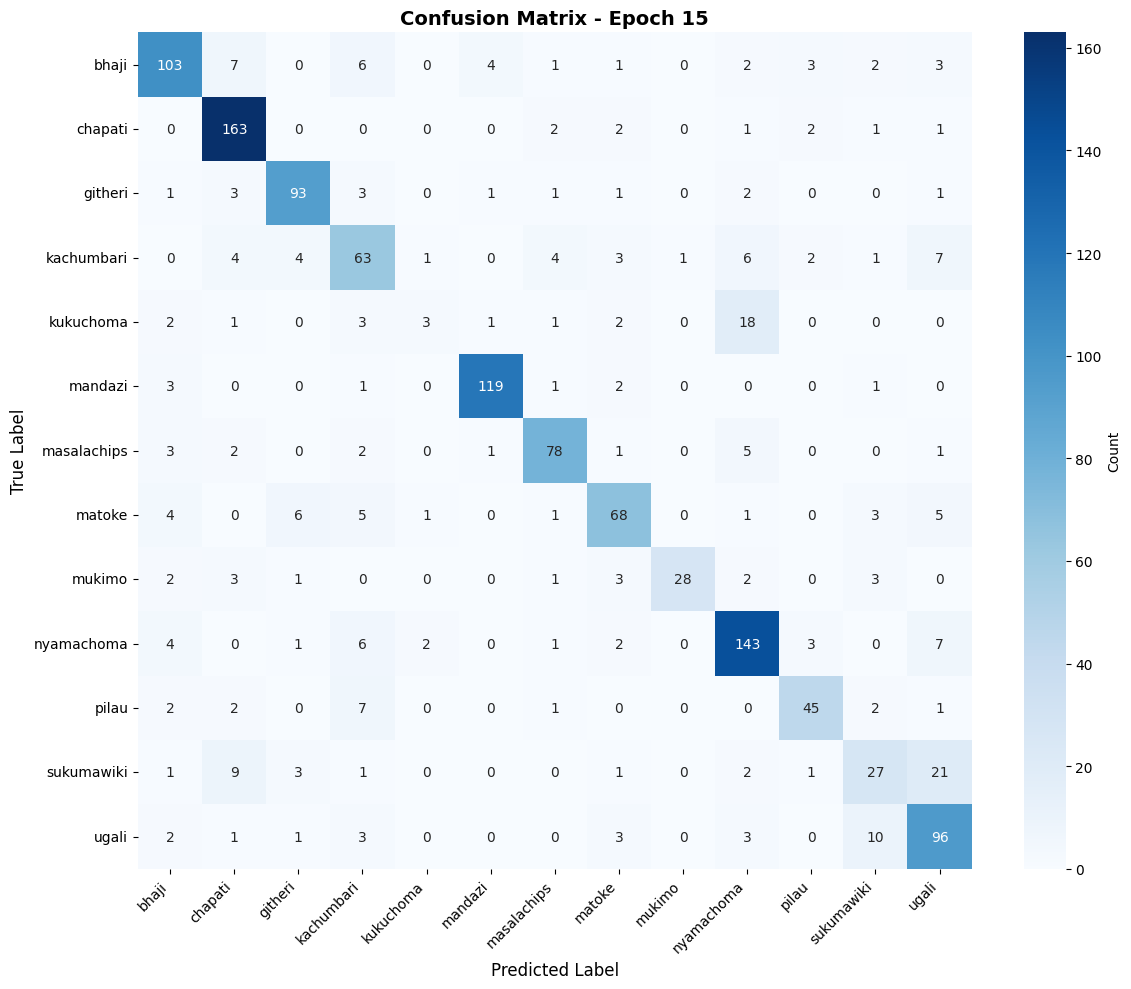

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_15.png

EMA Model Improved... Saving... Done.




Valid:	Epoch: 16/200	Loss: 1.0694, Acc: 0.7867: 100%|██████████| 41/41 [00:11<00:00,  3.63it/s]



Train Loss: 1.3951    Train Acc: 0.7493
Val Loss: 1.0694      Val Acc: 0.7867
Current Learning Rate: 0.000993844785880539


EMA Model Improved... Saving... Done.




Valid:	Epoch: 17/200	Loss: 1.0690, Acc: 0.7844: 100%|██████████| 41/41 [00:11<00:00,  3.63it/s]



Train Loss: 1.3646    Train Acc: 0.7669
Val Loss: 1.0690      Val Acc: 0.7844
Current Learning Rate: 0.000975530705321762


EMA Model Improved... Saving... Done.




...


Train Loss: 1.3772    Train Acc: 0.7556
Val Loss: 1.0625      Val Acc: 0.7913
Current Learning Rate: 0.0009455087117679744


EMA Model Improved... Saving... Done.




Train:	 Epoch: 19/200	Loss:1.3976, Acc: -- (mixup): 100%|██████████| 164/164 [01:17<00:00,  2.12it/s]
Valid:	Epoch: 19/200	Loss: 1.0604, Acc: 0.7905: 100%|██████████| 41/41 [00:11<00:00,  3.57it/s]



Train Loss: 1.3976    Train Acc: 0.7804
Val Loss: 1.0604      Val Acc: 0.7905
Current Learning Rate: 0.0009045180463377549


EMA Model Improved... Saving... Done.




Train:	 Epoch: 20/200	Loss:1.3828, Acc: -- (mixup): 100%|██████████| 164/164 [01:16<00:00,  2.13it/s]
Valid:	Epoch: 20/200	Loss: 1.0571, Acc: 0.7905: 100%|██████████| 41/41 [00:11<00:00,  3.50it/s]



Train Loss: 1.3828    Train Acc: 0.7656
Val Loss: 1.0571      Val Acc: 0.7905
Current Learning Rate: 0.0008535680352542143



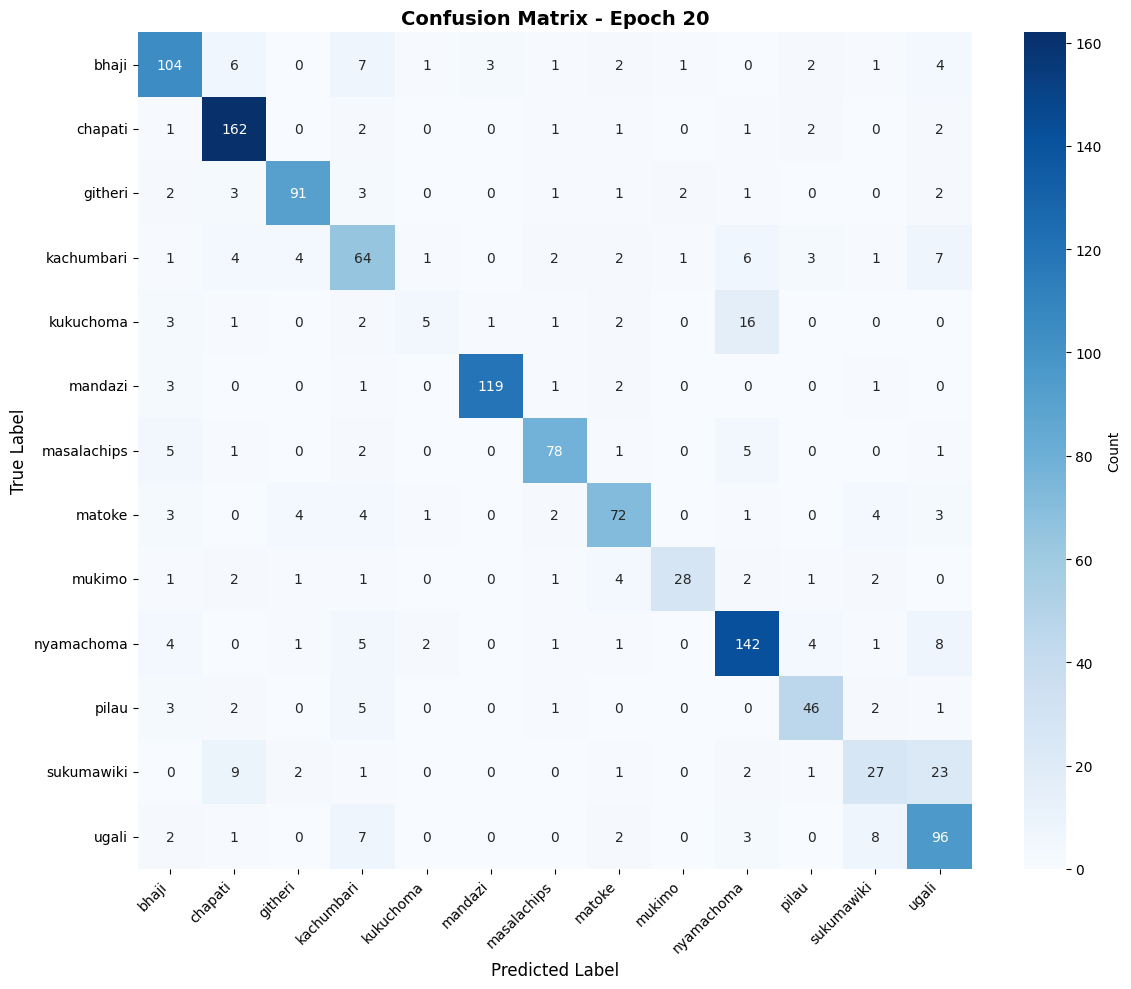

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_20.png

EMA Model Improved... Saving... Done.



UNFREEZING: Stage 1 + Stem | LR: 1e-5



Train:	 Epoch: 21/200	Loss:1.3038, Acc: -- (mixup): 100%|██████████| 164/164 [02:16<00:00,  1.20it/s]
Valid:	Epoch: 21/200	Loss: 1.0587, Acc: 0.7928: 100%|██████████| 41/41 [00:11<00:00,  3.50it/s]



Train Loss: 1.3038    Train Acc: 0.7869
Val Loss: 1.0587      Val Acc: 0.7928
Current Learning Rate: 0.0007939132368836219

Validation loss did not improve. Early Stopping: 1/12




Train:	 Epoch: 22/200	Loss:1.3118, Acc: -- (mixup): 100%|██████████| 164/164 [02:15<00:00,  1.21it/s]
Valid:	Epoch: 22/200	Loss: 1.0590, Acc: 0.7920: 100%|██████████| 41/41 [00:11<00:00,  3.42it/s]



Train Loss: 1.3118    Train Acc: 0.8086
Val Loss: 1.0590      Val Acc: 0.7920
Current Learning Rate: 0.0007270225503447864

Validation loss did not improve. Early Stopping: 2/12




...


Train Loss: 1.2974    Train Acc: 0.8016
Val Loss: 1.0572      Val Acc: 0.7936
Current Learning Rate: 0.0006545430463377549

Validation loss did not improve. Early Stopping: 3/12




Train:	 Epoch: 24/200	Loss:1.3169, Acc: -- (mixup): 100%|██████████| 164/164 [02:15<00:00,  1.21it/s]
Valid:	Epoch: 24/200	Loss: 1.0537, Acc: 0.7943: 100%|██████████| 41/41 [00:12<00:00,  3.42it/s]



Train Loss: 1.3169    Train Acc: 0.7955
Val Loss: 1.0537      Val Acc: 0.7943
Current Learning Rate: 0.0005782594107968633


EMA Model Improved... Saving... Done.




Train:	 Epoch: 25/200	Loss:1.3273, Acc: -- (mixup): 100%|██████████| 164/164 [02:15<00:00,  1.21it/s]
Valid:	Epoch: 25/200	Loss: 1.0537, Acc: 0.7943: 100%|██████████| 41/41 [00:12<00:00,  3.34it/s]



Train Loss: 1.3273    Train Acc: 0.8087
Val Loss: 1.0537      Val Acc: 0.7943
Current Learning Rate: 0.0005000499999999999



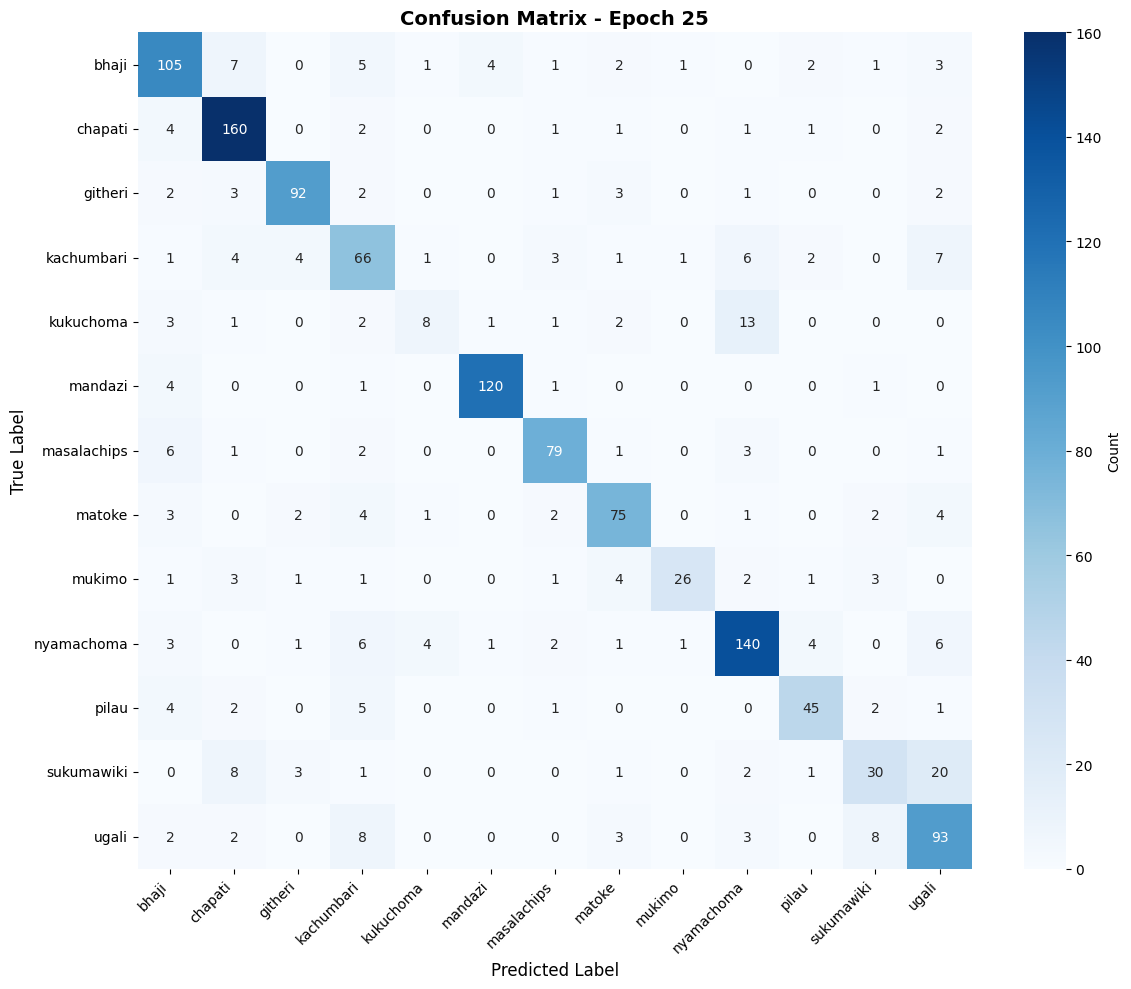

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_25.png
Validation loss did not improve. Early Stopping: 1/12




Train:	 Epoch: 26/200	Loss:1.3280, Acc: -- (mixup): 100%|██████████| 164/164 [02:14<00:00,  1.22it/s]
Valid:	Epoch: 26/200	Loss: 1.0530, Acc: 0.7997: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.3280    Train Acc: 0.8028
Val Loss: 1.0530      Val Acc: 0.7997
Current Learning Rate: 0.0004218405892031367


EMA Model Improved... Saving... Done.




Valid:	Epoch: 27/200	Loss: 1.0551, Acc: 0.7966: 100%|██████████| 41/41 [00:12<00:00,  3.32it/s]



Train Loss: 1.2054    Train Acc: 0.8299
Val Loss: 1.0551      Val Acc: 0.7966
Current Learning Rate: 0.00034555695366224505

Validation loss did not improve. Early Stopping: 1/12




...


Train Loss: 1.2484    Train Acc: 0.8132
Val Loss: 1.0523      Val Acc: 0.7974
Current Learning Rate: 0.0002730774496552136


EMA Model Improved... Saving... Done.




Train:	 Epoch: 29/200	Loss:1.2686, Acc: -- (mixup): 100%|██████████| 164/164 [02:14<00:00,  1.22it/s]
Valid:	Epoch: 29/200	Loss: 1.0509, Acc: 0.7982: 100%|██████████| 41/41 [00:12<00:00,  3.39it/s]



Train Loss: 1.2686    Train Acc: 0.8158
Val Loss: 1.0509      Val Acc: 0.7982
Current Learning Rate: 0.0002061867631163781


EMA Model Improved... Saving... Done.




Valid:	Epoch: 30/200	Loss: 1.0497, Acc: 0.8020: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 1.1993    Train Acc: 0.8419
Val Loss: 1.0497      Val Acc: 0.8020
Current Learning Rate: 0.0001465319647457856



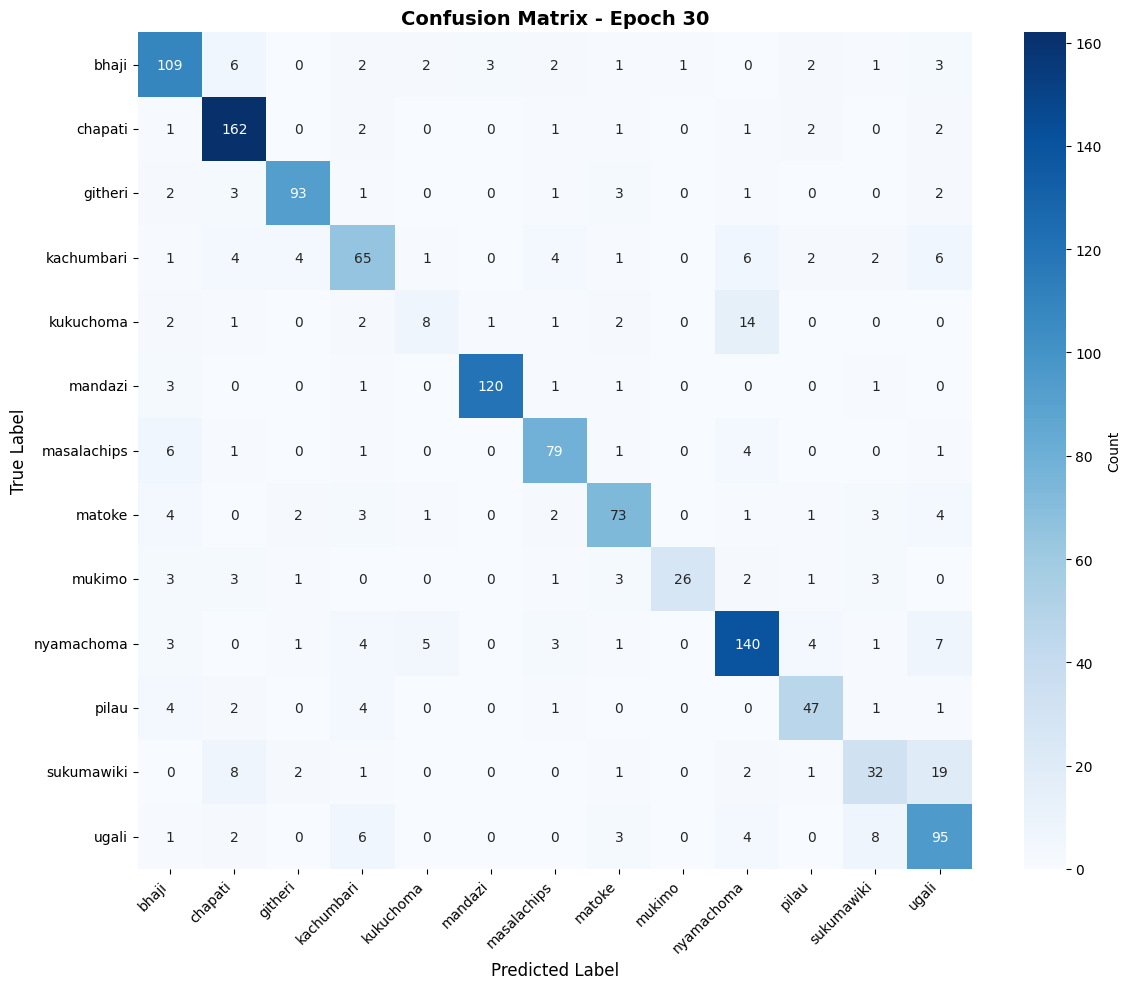

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_30.png

EMA Model Improved... Saving... Done.




Train:	 Epoch: 31/200	Loss:1.2274, Acc: -- (mixup): 100%|██████████| 164/164 [02:16<00:00,  1.20it/s]
Valid:	Epoch: 31/200	Loss: 1.0476, Acc: 0.7997: 100%|██████████| 41/41 [00:11<00:00,  3.43it/s]



Train Loss: 1.2274    Train Acc: 0.8345
Val Loss: 1.0476      Val Acc: 0.7997
Current Learning Rate: 9.558195366224507e-05


EMA Model Improved... Saving... Done.




Valid:	Epoch: 32/200	Loss: 1.0465, Acc: 0.8005: 100%|██████████| 41/41 [00:11<00:00,  3.44it/s]



Train Loss: 1.1756    Train Acc: 0.8448
Val Loss: 1.0465      Val Acc: 0.8005
Current Learning Rate: 5.459128823202553e-05


EMA Model Improved... Saving... Done.




...


Train Loss: 1.1736    Train Acc: 0.8371
Val Loss: 1.0467      Val Acc: 0.7989
Current Learning Rate: 2.456929467823799e-05

Validation loss did not improve. Early Stopping: 1/12




Valid:	Epoch: 34/200	Loss: 1.0465, Acc: 0.8020: 100%|██████████| 41/41 [00:11<00:00,  3.47it/s]



Train Loss: 1.2008    Train Acc: 0.8465
Val Loss: 1.0465      Val Acc: 0.8020
Current Learning Rate: 6.255214119460927e-06

Validation loss did not improve. Early Stopping: 2/12




Valid:	Epoch: 35/200	Loss: 1.0466, Acc: 0.8020: 100%|██████████| 41/41 [00:11<00:00,  3.46it/s]



Train Loss: 1.2005    Train Acc: 0.8548
Val Loss: 1.0466      Val Acc: 0.8020
Current Learning Rate: 0.001



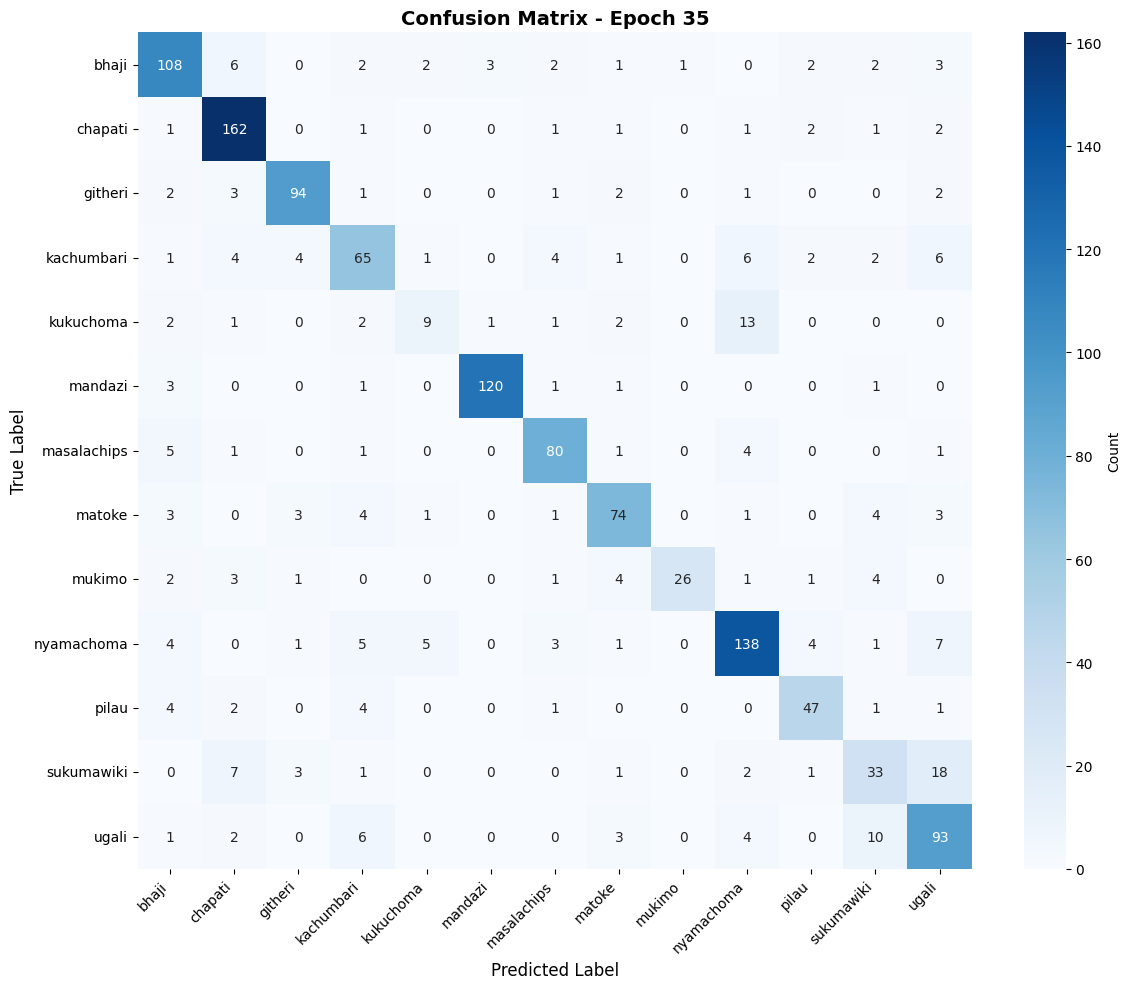

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_35.png
Validation loss did not improve. Early Stopping: 3/12




Valid:	Epoch: 36/200	Loss: 1.0467, Acc: 0.8035: 100%|██████████| 41/41 [00:11<00:00,  3.48it/s]



Train Loss: 1.2445    Train Acc: 0.8091
Val Loss: 1.0467      Val Acc: 0.8035
Current Learning Rate: 0.0009984588209998775

Validation loss did not improve. Early Stopping: 4/12




Valid:	Epoch: 37/200	Loss: 1.0462, Acc: 0.7989: 100%|██████████| 41/41 [00:11<00:00,  3.56it/s]



Train Loss: 1.2978    Train Acc: 0.8006
Val Loss: 1.0462      Val Acc: 0.7989
Current Learning Rate: 0.000993844785880539


EMA Model Improved... Saving... Done.




...


Train Loss: 1.3258    Train Acc: 0.7989
Val Loss: 1.0427      Val Acc: 0.8035
Current Learning Rate: 0.0009861863417028184


EMA Model Improved... Saving... Done.




Valid:	Epoch: 39/200	Loss: 1.0419, Acc: 0.7966: 100%|██████████| 41/41 [00:11<00:00,  3.50it/s]



Train Loss: 1.3024    Train Acc: 0.8146
Val Loss: 1.0419      Val Acc: 0.7966
Current Learning Rate: 0.000975530705321762


EMA Model Improved... Saving... Done.




Train:	 Epoch: 40/200	Loss:1.2808, Acc: -- (mixup): 100%|██████████| 164/164 [02:15<00:00,  1.21it/s]
Valid:	Epoch: 40/200	Loss: 1.0440, Acc: 0.8073: 100%|██████████| 41/41 [00:11<00:00,  3.60it/s]



Train Loss: 1.2808    Train Acc: 0.8034
Val Loss: 1.0440      Val Acc: 0.8073
Current Learning Rate: 0.0009619435722790177



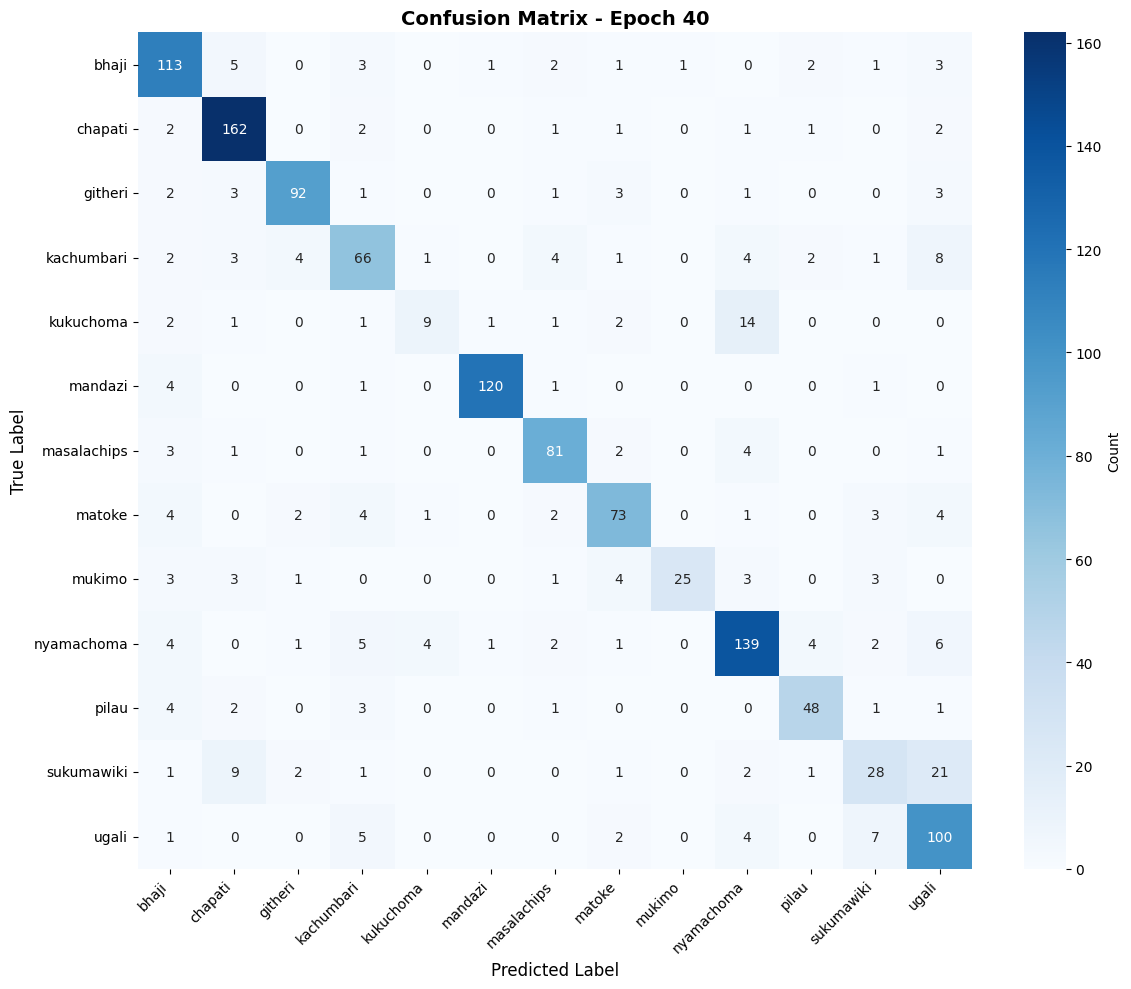

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_40.png
Validation loss did not improve. Early Stopping: 1/12




Valid:	Epoch: 41/200	Loss: 1.0476, Acc: 0.8043: 100%|██████████| 41/41 [00:11<00:00,  3.58it/s]



Train Loss: 1.3328    Train Acc: 0.8167
Val Loss: 1.0476      Val Acc: 0.8043
Current Learning Rate: 0.0009455087117679744

Validation loss did not improve. Early Stopping: 2/12




Valid:	Epoch: 42/200	Loss: 1.0483, Acc: 0.8005: 100%|██████████| 41/41 [00:11<00:00,  3.52it/s]



Train Loss: 1.2565    Train Acc: 0.8281
Val Loss: 1.0483      Val Acc: 0.8005
Current Learning Rate: 0.0009263274501688283

Validation loss did not improve. Early Stopping: 3/12




...


Train Loss: 1.2794    Train Acc: 0.8155
Val Loss: 1.0508      Val Acc: 0.7966
Current Learning Rate: 0.0009045180463377549

Validation loss did not improve. Early Stopping: 4/12




Valid:	Epoch: 44/200	Loss: 1.0491, Acc: 0.7966: 100%|██████████| 41/41 [00:11<00:00,  3.65it/s]



Train Loss: 1.2555    Train Acc: 0.8240
Val Loss: 1.0491      Val Acc: 0.7966
Current Learning Rate: 0.0008802149625017355

Validation loss did not improve. Early Stopping: 5/12




Valid:	Epoch: 45/200	Loss: 1.0460, Acc: 0.7974: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]



Train Loss: 1.2432    Train Acc: 0.8298
Val Loss: 1.0460      Val Acc: 0.7974
Current Learning Rate: 0.0008535680352542143



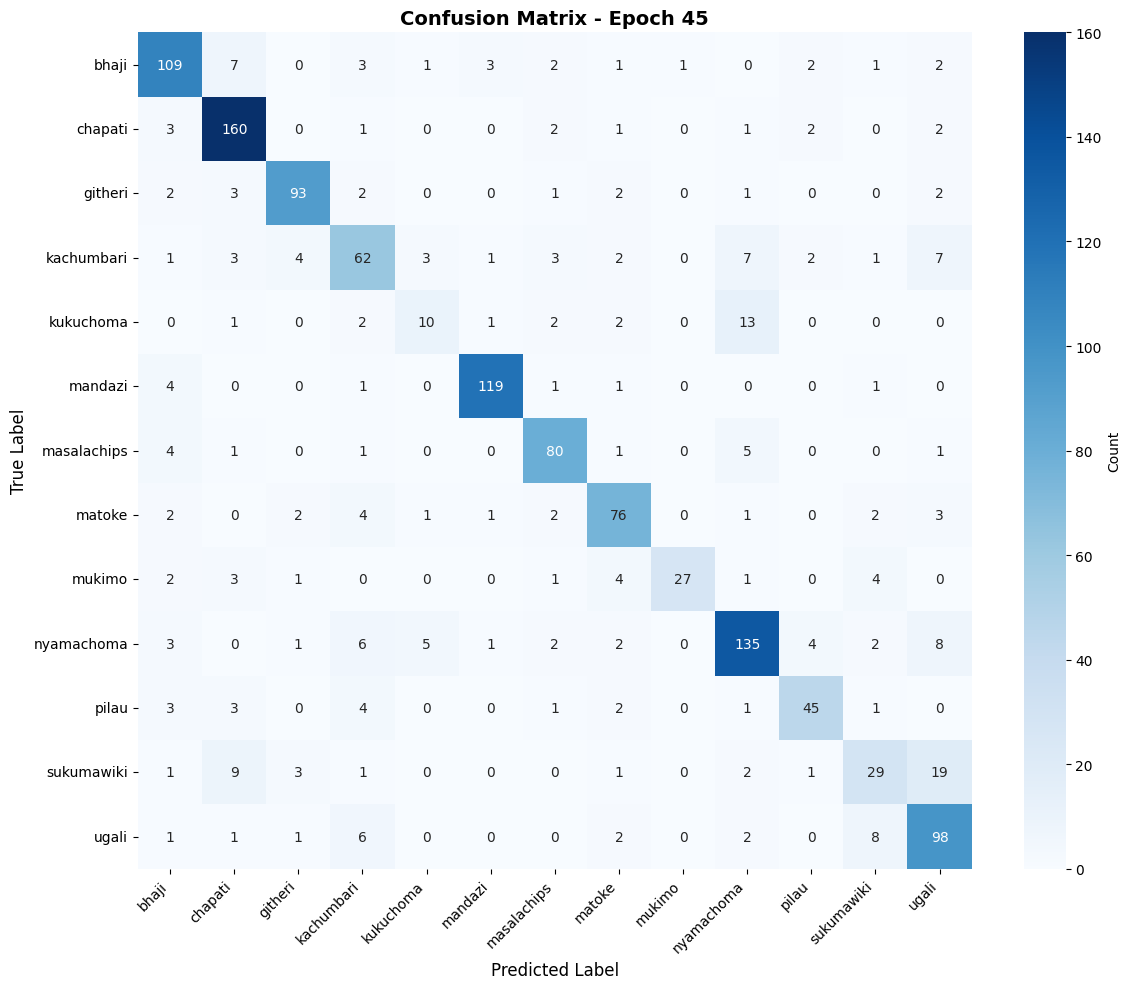

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_45.png
Validation loss did not improve. Early Stopping: 6/12




Valid:	Epoch: 46/200	Loss: 1.0483, Acc: 0.7936: 100%|██████████| 41/41 [00:12<00:00,  3.35it/s]



Train Loss: 1.1628    Train Acc: 0.8303
Val Loss: 1.0483      Val Acc: 0.7936
Current Learning Rate: 0.0008247415517626753

Validation loss did not improve. Early Stopping: 7/12




Train:	 Epoch: 47/200	Loss:1.2255, Acc: -- (mixup): 100%|██████████| 164/164 [02:14<00:00,  1.22it/s]
Valid:	Epoch: 47/200	Loss: 1.0532, Acc: 0.7920: 100%|██████████| 41/41 [00:12<00:00,  3.40it/s]



Train Loss: 1.2255    Train Acc: 0.8355
Val Loss: 1.0532      Val Acc: 0.7920
Current Learning Rate: 0.0007939132368836219

Validation loss did not improve. Early Stopping: 8/12




...


Train Loss: 1.1887    Train Acc: 0.8511
Val Loss: 1.0514      Val Acc: 0.7920
Current Learning Rate: 0.0007612731574297385

Validation loss did not improve. Early Stopping: 9/12




Train:	 Epoch: 49/200	Loss:1.1912, Acc: -- (mixup): 100%|██████████| 164/164 [02:14<00:00,  1.22it/s]
Valid:	Epoch: 49/200	Loss: 1.0542, Acc: 0.7959: 100%|██████████| 41/41 [00:11<00:00,  3.45it/s]



Train Loss: 1.1912    Train Acc: 0.8348
Val Loss: 1.0542      Val Acc: 0.7959
Current Learning Rate: 0.0007270225503447864

Validation loss did not improve. Early Stopping: 10/12




Train:	 Epoch: 50/200	Loss:1.2306, Acc: -- (mixup): 100%|██████████| 164/164 [02:14<00:00,  1.22it/s]
Valid:	Epoch: 50/200	Loss: 1.0546, Acc: 0.7959: 100%|██████████| 41/41 [00:11<00:00,  3.48it/s]



Train Loss: 1.2306    Train Acc: 0.8507
Val Loss: 1.0546      Val Acc: 0.7959
Current Learning Rate: 0.0006913725820109265



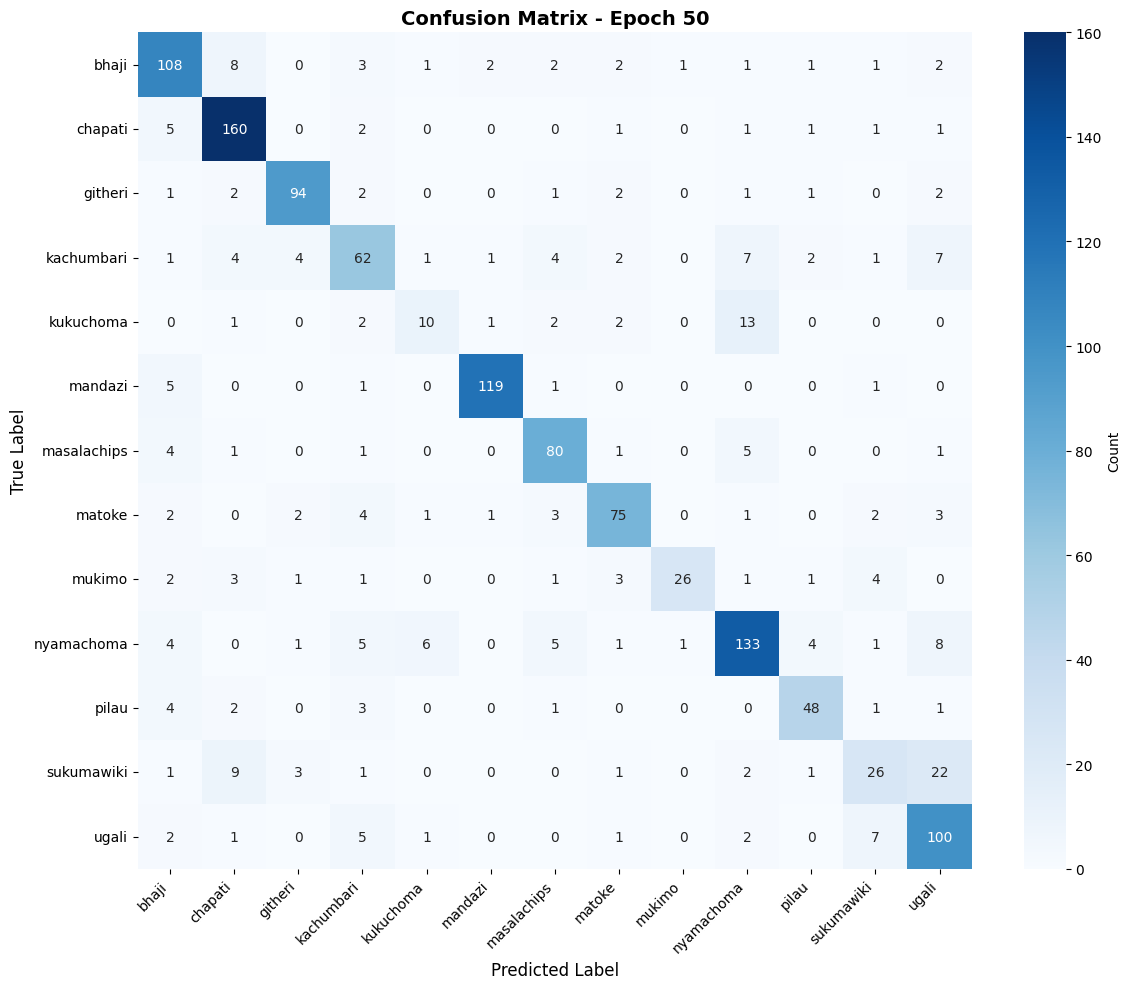

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_50.png
Validation loss did not improve. Early Stopping: 11/12




Train:	 Epoch: 51/200	Loss:1.1440, Acc: -- (mixup): 100%|██████████| 164/164 [02:15<00:00,  1.21it/s]
Valid:	Epoch: 51/200	Loss: 1.0535, Acc: 0.7943: 100%|██████████| 41/41 [00:11<00:00,  3.52it/s]



Train Loss: 1.1440    Train Acc: 0.8492
Val Loss: 1.0535      Val Acc: 0.7943
Current Learning Rate: 0.0006545430463377549

Validation loss did not improve. Early Stopping: 12/12

Early Stopping Triggered! Training stopped at epoch 51 to avoid overfitting.

Total time: 6334.05s, Best Loss: 1.042

Generating final confusion matrix on best model...


Valid:	Epoch: 200/200	Loss: 1.0419, Acc: 0.7966: 100%|██████████| 41/41 [00:11<00:00,  3.47it/s]


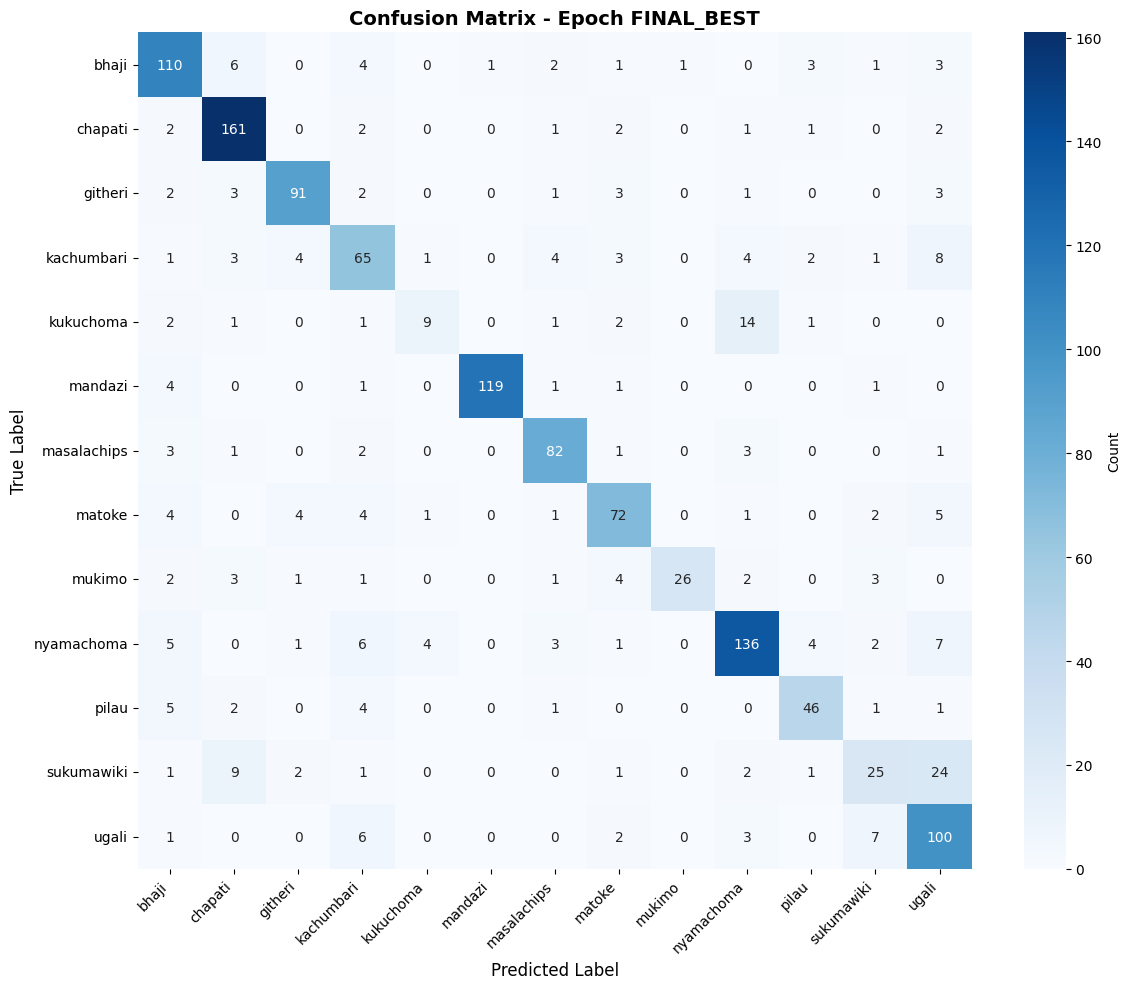

Confusion matrix saved to: confusion_matrices/conf_matrix_epoch_FINAL_BEST.png


In [36]:
writer = SummaryWriter(TrainingConfig.LOG_DIR)

history = main(
    DEVICE,
    model = model_net,
    optimizer = optimizer_net,
    ema_model=ema,
    ckpt_dir = CKPT_DIR,
    summary_writer =  writer,
    data_config = DatasetConfig(),
    train_config = TrainingConfig(),
    class_to_idx = class_to_idx
)

writer.close()

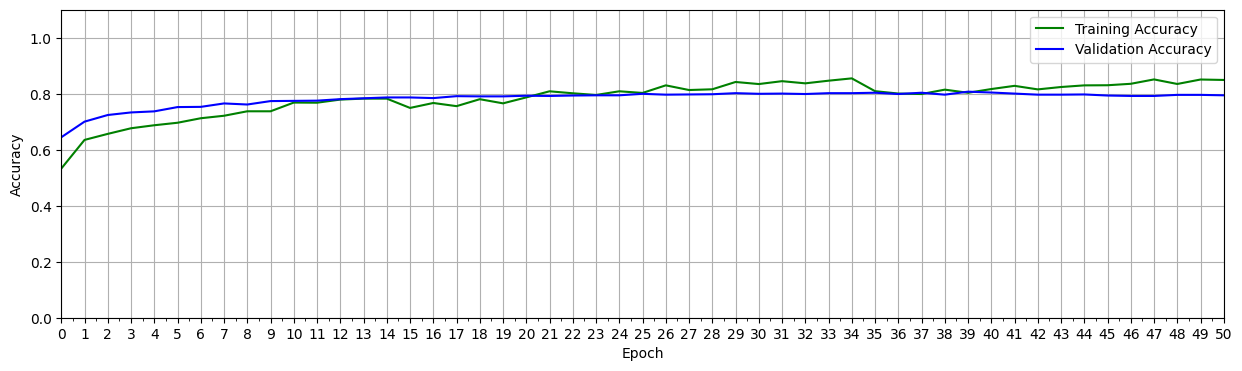

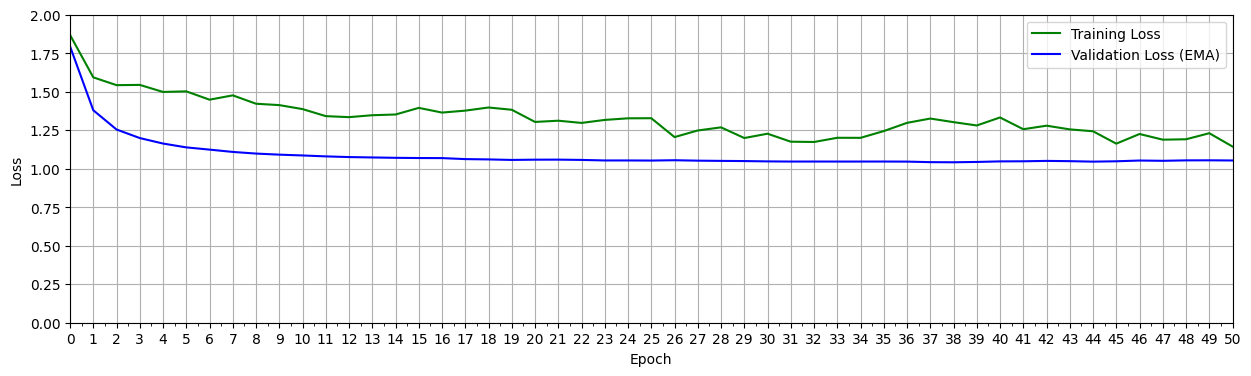

In [37]:
# Retrieve training results.
train_loss = history["train_loss"]
train_acc  = history["train_acc"]
valid_loss = history["valid_loss"]
valid_acc  = history["valid_acc"]

train_config = history["train_config"]

plot_results([ train_acc, valid_acc ],
            ylabel="Accuracy",
            ylim = [0.0, 1.1],
            metric_name=["Training Accuracy", "Validation Accuracy"],
            color=["g", "b"],
            training_config=TrainingConfig())

plot_results([ train_loss, valid_loss ],
            ylabel="Loss",
            ylim = [0.0, 2.0],
            metric_name=["Training Loss", "Validation Loss (EMA)"],
            color=["g", "b"],
            training_config=TrainingConfig());

In [38]:
def prediction_batch(model: nn.Module, 
                     batch_inputs: torch.Tensor, 
                     device: torch.device):
    
    # Ensure model is in evaluation mode
    model.eval()

    # Move inputs to the correct device (CPU/CUDA)
    batch_inputs = batch_inputs.to(device)

    # Forward pass without tracking gradients
    with torch.no_grad():
        batch_ops = model(batch_inputs)

    # Calculate probabilities
    batch_probs = batch_ops.softmax(dim=1)

    # Extract max confidence values and their respective class IDs
    batch_confs, batch_cls_ids = batch_probs.max(dim=1)

    # Return them as separate tensors on the CPU
    return batch_confs.cpu(), batch_cls_ids.cpu()

In [39]:
# Load best EMA weights
checkpoint_path = os.path.join(TrainingConfig.CHECKPOINT_DIR, "best_ema_model.pth")

if os.path.exists(checkpoint_path):
    print(f"Loading best EMA weights from: {checkpoint_path}")
    
    # Load the weights dictionary safely to your current active device
    best_weights = torch.load(checkpoint_path, map_location=DEVICE)
    
    # Inject the saved weights back into your model instance
    model_net.load_state_dict(best_weights)
    
    # Send model to accelerator and lock model state for validation testing
    model_net = model_net.to(DEVICE)
    model_net.eval()
    print("--> Best EMA model restored for inference!")
else:
    print(f"CRITICAL WARNING: Checkpoint file not found at {checkpoint_path}!")
    print("Inference will continue using your current, un-restored model weights (Epoch 10 structure).")

Loading best EMA weights from: model_checkpoint/kenya_food_models/best_ema_model.pth
--> Best EMA model restored for inference!


In [40]:
# Setup containers
all_confs = []
all_preds = []
all_ids = []

# Loop through the unlabelled test data
for images, ids in test_loader:
    # Get predictions using your function
    confs, preds = prediction_batch(model_net, images, DEVICE)
    
    # Store results
    all_confs.extend(confs.numpy())
    all_preds.extend(preds.numpy())
    all_ids.extend(ids)

# Create a clean final dataframe
results_df = pd.DataFrame({
    'id': all_ids,
    'class_id': all_preds,
    'confidence': all_confs
})

In [41]:
# Grab the original class_to_idx mapping from your training dataset
class_to_idx = train_loader.dataset.class_to_idx

# Invert the dictionary: turns { 'ugali': 0 } into { 0: 'ugali' }
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

# Use pandas .map() to create the new column
results_df['class_name'] = results_df['class_id'].map(idx_to_class)

In [42]:
# Keep only the columns needed for submission
submission_df = results_df[['id', 'class_name']]

# Rename columns if the competition requires specific headers (e.g., 'label')
submission_df = submission_df.rename(columns={'class_name': 'class'})

# Save it to a CSV file
submission_df.to_csv('kenyan_food_submission.csv', index=False)

## <font style="color:green">8. TensorBoard Log Link [5 Points]</font>

**Share your TensorBoard scalars logs link here You can also share (not mandatory) your GitHub link, if you have pushed this project in GitHub.**


Note: In light of the recent shutdown of tensorboard.dev, we have updated the submission requirements for your project. Instead of sharing a tensorboard.dev link, you are now required to upload your generated TensorBoard event files directly onto the lab. As an alternative, you may also include a screenshot of your TensorBoard output within your Jupyter notebook. This adjustment ensures that your data visualization and model training efforts are thoroughly documented and accessible for evaluation.

You are also welcome (and encouraged) to utilize alternative logging services like wandB or comet. In such instances, you can easily make your project logs publicly accessible and share the link with others.

## <font style="color:green">9. Kaggle Profile Link [50 Points]</font>

**Share your Kaggle profile link  with us here to score , points in  the competition.**

**For full points, you need a minimum accuracy of `75%` on the test data. If accuracy is less than `70%`, you gain  no points for this section.**


**Submit `submission.csv` (prediction for images in `test.csv`), in the `Submit Predictions` tab in Kaggle, to get evaluated for  this section.**